In this notebook, we provide intuition about explainability for black-box models. Black-box models are those that are too complex for a human to directly understand, such as neural networks and ensemble methods like gradient boosting (e.g. XGBoost, LightGBM, CatBoost).

Before starting, it is worth clarifying the difference between interpretable models and explainable models:

Interpretable models are those where we can directly understand how changes in the inputs affect the output, just by looking at the model itself.
This is the case for linear regression, where each variable is associated with a coefficient that indicates how it influences the prediction. It is also true for a single decision tree, where, by following the branches, we can understand exactly how a prediction is made.

In contrast, models such as random forests and gradient boosting (e.g. XGBoost, LightGBM), which combine many trees, or neural networks with thousands or millions of parameters, are too complex for this type of direct interpretation. In these cases, we rely on explainability methods to understand how the model is using the input features to produce its predictions.

To provide explainability for such models, we typically take a trained model and analyse how changes in the input features affect its output. There are many approaches to do this (e.g. partial dependence plots, ICE plots, LIME), but one of the most widely used and mathematically grounded methods is SHAP.

SHAP (SHapley Additive exPlanations) is based on game theory and computes Shapley values, which quantify how much each feature contributes to a model’s prediction. These contributions can be analysed both globally (across the dataset) and locally (for individual predictions).

In this notebook, we use the SHAP python library to explore these ideas. We start with a simple, interpretable model (linear regression), and then move to a more complex model (LightGBM). Along the way, we introduce some of the most commonly used plots to explain model behaviour.

In [2]:
import numpy as np
import pandas as pd
import sklearn
import shap
import matplotlib.pyplot as plt
import plotly.express as px
import lightgbm as lgb
import optuna # for a quick lightgbm hyperparameter tuning
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

For this exercise, we leverage the California Housing dataset as ground truth. Which takes the following variables associated with the price of the house:

- MedInc (float): Median income in block
- HouseAge (float): Median house age in block
- AveRooms (float): Average rooms in dwelling
- AveBedrms (float): Average bedrooms in dwelling
- Population (float): Block population
- AveOccup (float): Average house occupancy
- Latitude (float): House block latitude
- Longitude (float): House block longitude

To predict the variable of interest:

- MedHouseVal (float): Median House Value, expressed in units of $100,000 (e.g., a value of 4.526 represents $452,600)

In [3]:
X, y = shap.datasets.california(n_points=1000) # The dataset
X, X_valid, y, y_valid = sklearn.model_selection.train_test_split(X, y, test_size=0.1, random_state=42)

# Linear Regression (Interpretable model)

Linear regression is a simple yet powerful model that is particularly easy to interpret. This is because, after the model is fit, each variable is associated with a parameter (coefficient) that it is multiplied by, transforming its value into the units of the variable of interest. The sum of all these transformed variables, plus an offset (intercept), is what produces the final prediction.

For example, by analysing the parameters of an already fit house price prediction model, we can get an idea of how each variable influences the price of a house in our dataset:

HousePrice = MedInc * (0.4) + AveBedrms * (5000) + Latitude * (-0.5) + 50000

- The offset suggests that the baseline value of a house, when all variables are zero, is 50,000.
- Median income in the block (MedInc) increases the price of the house at a rate of 0.4 (each additional dollar in income adds 0.4 dollars to the predicted house price), and each additional bedroom adds 5,000 dollars.
- Latitude has a negative coefficient, suggesting that as we move north (latitude increases), house prices decrease. Since latitude increases northward, the negative coefficient implies a downward effect on price.

This initial interpretation is useful; however, there is an important limitation: the scale of the parameters can be misleading without context. If variables are not normalised, those with large numerical scales will tend to have smaller coefficients, and vice versa.

For example, if median house age ("HouseAge") were measured in seconds instead of years, its coefficient would be much smaller, simply because the input values are much larger. This could give the misleading impression that HouseAge is less important than other variables, when in reality the difference is only due to the units of measurement. In contrast, a variable like AveBedrms might have a larger coefficient simply because it operates on a smaller numerical scale.

Now to the actual model on our dataset:

In [4]:
model = sklearn.linear_model.LinearRegression()
model.fit(X, y)

print("Model coefficients:\n")
for i in range(X.shape[1]):
    print(X.columns[i], "=", model.coef_[i].round(5))
print("Intercept = ", model.intercept_.round(5))

print("\nModel performance metrics:\n")
r2 = sklearn.metrics.r2_score(y_valid, model.predict(X_valid))
mae = sklearn.metrics.mean_absolute_error(y_valid, model.predict(X_valid))
print("r2 score: ",r2)
print("mae: ",mae)

Model coefficients:

MedInc = 0.41174
HouseAge = 0.00932
AveRooms = -0.109
AveBedrms = 0.63208
Population = 4e-05
AveOccup = -0.25315
Latitude = -0.46534
Longitude = -0.46173
Intercept =  -37.84145

Model performance metrics:

r2 score:  0.6822806366957337
mae:  0.5473856962442352


The analysis we did works well, but it provides a static, global understanding of how each variable affects the output across all samples. It fails to capture interactions between variables and is mainly limited to linear models. If we were using more complex models (e.g. neural networks or tree-based models), this type of interpretation would not be sufficient to understand the relationships being learned.

This is where SHAP comes in. SHAP (Shapley values) is a method based on game theory that allows us to understand the marginal contribution of each feature to a model’s prediction. We will omit the theory behind it, but intuitively, it tells us how each feature steers a prediction away from the model’s average prediction. To make this easier to understand, we can compare it to linear regression. In linear regression, the intercept acts as a baseline, and each feature multiplied by its coefficient shifts the prediction away from that baseline. In SHAP, the baseline is the average prediction of the model across the dataset (the expected value), and the Shapley value of each feature represents how much that feature contributes to moving from this baseline to the final prediction for a given sample.

Unlike linear regression coefficients, which provide a single global interpretation, SHAP allows us to compute per-sample explanations, showing how each feature contributes to an individual prediction, not just on average across the dataset.

Below, we take a subsample of the data to use as a reference dataset for comparisons (we could use the full dataset, but that would be computationally expensive). We then create an explainer object for the linear regression model we trained, compute the SHAP values (which represent the contribution of each feature to each prediction), and select a specific sample (sample #20) to analyse the relationships captured by the model.

Note: To understand the underlying SHAP algorithm, refer to: https://christophm.github.io/interpretable-ml-book/shapley.html 

In [5]:
X100 = shap.utils.sample(X, 100) # Subsample to use as background dataset (SHAP needs one for its internal algorithm)
explainer = shap.Explainer(model.predict, X100)
shap_values = explainer(X)
sample_ind = 20

Having SHAP values computed allows us to draw different plots to better understand the reasons behind a model’s predictions.

## Dependence plot (+ ICE lines)

A dependence plot helps us understand how the model output changes as a feature varies, as well as how frequently different values of that feature occur in the data. More specifically, it shows how the model’s prediction evolves across the range of a feature, while also giving a sense of how common those values are. This helps us see not only the effect of a feature, but also how relevant that effect is in practice. As a result, values that have a strong effect but occur rarely may end up being less important overall than values that have a weaker effect but occur frequently.

In the plot below, we overlay both the dependence plot and the Individual Conditional Expectation (ICE) lines, displaying one line per instance that shows how the instance’s prediction changes when a feature changes. We show the behaviour for the variable "Latitude":

- The average value of the feature Latitude (grey vertical dashed line), at around 36
- The average model prediction for the price of a house (grey horizontal dashed line), at nearly 2 ($200.000).
- The bold blue line represents the average model prediction as we vary Latitude across its range (this is the partial dependence, i.e. the global trend)
- The lighter blue lines represent the model predictions for individual samples as we vary Latitude (ICE curves). Each line corresponds to one sample, where we change only the Latitude and keep the rest of the features fixed
- The red vertical segment marks the selected sample (sample_ind). It shows how that specific sample’s prediction shifts relative to the baseline (expected value), highlighting the contribution of Latitude for that instance

All the blue lines are linear because the underlying model is a linear regression. We can clearly see a negative relationship: as Latitude increases (moving north), the predicted house price decreases across all samples.

The spread of ICE lines does not indicate how important a feature is, but rather how consistent its effect is across samples. If the lines are tightly grouped, the feature has a similar effect across the dataset. If they are widely spread, the feature interacts with other variables, and its effect depends on the specific sample.

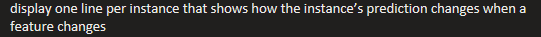
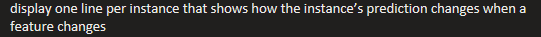
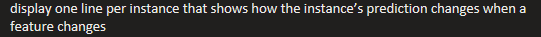

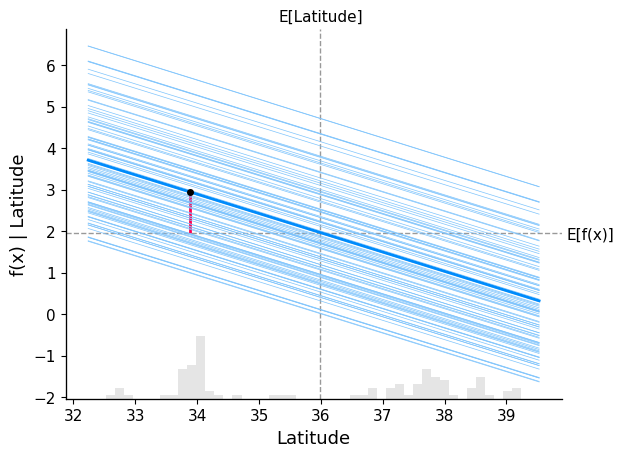

In [6]:
shap.partial_dependence_plot(
    "Latitude",
    model.predict,
    X100,
    ice=True, # Change to false to see only general trend
    model_expected_value=True,
    feature_expected_value=True,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

## Scatter Plot

Another way to visualise how a variable influences the model output is through a scatter plot. In this plot, we place the feature values on the x-axis and their corresponding SHAP values on the y-axis, showing how changes in the feature affect the prediction.

By passing shap_values to the "color" argument, SHAP automatically selects the feature that is most strongly correlated (or interacting) with the SHAP values of the selected feature, and uses it to colour the points.

In our example, we analyse Latitude, and SHAP identifies Longitude as the feature most related to it, which is then shown through the colour scale. (Please note that this is consistent with the wide spread on the lines in the ICE plot above associated with interaction with another variable)

In this plot, we observe that:

- Points with lower latitude (further south) tend to have higher longitude values (red), meaning they are also located more to the east
- Points with higher latitude (further north) tend to have lower longitude values (blue), meaning they are also located more to the west

This pattern is consistent with the density of houses around the two main population centres in California: San Francisco (northwest) and Los Angeles (southeast).

The SHAP values follow a clear negative linear trend (as expected from a linear model), showing that as latitude increases, its contribution to the prediction decreases.

This implies that:

- Houses in the southeast (low latitude, high longitude) tend to have a positive contribution to the predicted price
- Houses in the northwest (high latitude, low longitude) tend to have a negative contribution to the predicted price

In other words, in this dataset, the model associates southeastern locations with higher predicted prices and northwestern locations with lower predicted prices. 

Note: It may be the case that houses in Los Angeles are more expensive than those in San Francisco, and that the geographic location of these cities is driving the pattern we observe. However, this analysis is purely observational, and we are not performing any hypothesis testing or causal inference here.

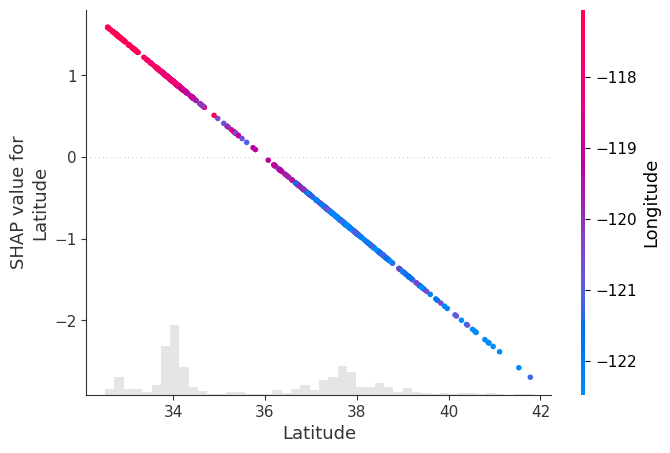

In [7]:
shap.plots.scatter(shap_values[:, "Latitude"], color=shap_values)

## Waterfall Plot

This plot gives us a per-sample explanation of the model’s prediction, showing how each variable contributed to the final output for a single observation, rather than how a variable behaves across the entire dataset.

In the plot below, we see how each feature contributes to moving the model’s expected value (the average prediction across all samples, E[f(X)]) to the final prediction for a specific sample (sample_ind).

Starting from an expected house price of E[f(X)], each variable adds or subtracts from this baseline until we reach the final prediction for that sample, f(x). We can verify this by comparing the model prediction of that specific sample, and the one shown on the plot at f(x):

In [8]:
model.predict(X.iloc[[sample_ind], :])

array([1.9473549])

From the plot, we observe that:

- Variables shown in blue contribute to pulling the prediction downwards
- Variables shown in red contribute to pushing the prediction upwards

The magnitude of each bar represents how much that feature contributes to the prediction for this specific sample.

These individual contributions are what we call SHAP values: they quantify how much each feature shifts the prediction away from the baseline E[f(X)] to reach the final output.

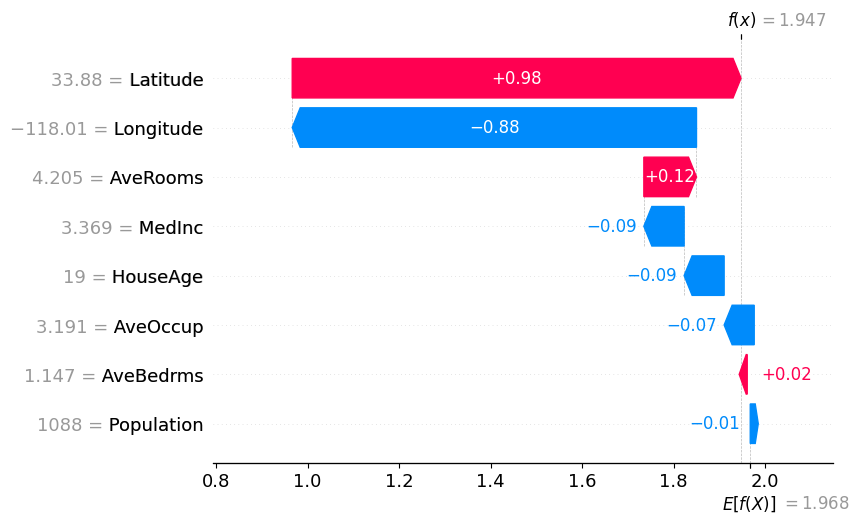

In [9]:
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

Note: Compare the waterfall plot and the dependence plot, and observe how the SHAP value for the Latitude variable is consistent in both.

## Beeswarm Plot

This plot shows the SHAP values of every variable across all samples. Each point represents a sample, positioned according to its SHAP value (impact on the model output), while the colour indicates the value of the feature (red = high value, blue = low value).

This allows us to understand both:

- How the value of a feature influences the prediction
- How common different effects are (denser regions indicate more samples with similar contributions)

Below is the beeswarm plot for our California housing dataset:

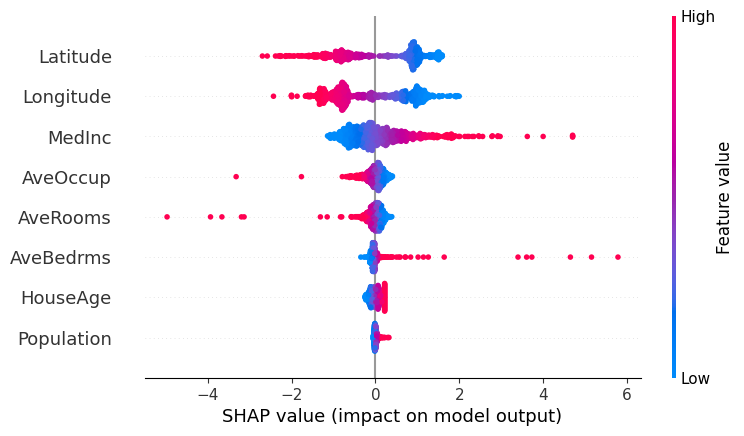

In [10]:
shap.plots.beeswarm(shap_values)

Analysing the plot, we can observe:

- MedInc and AveBedrms:
Both features show a right-skewed pattern in their SHAP values, with a few samples having very large positive contributions. In particular, higher values (red) are associated with strong positive SHAP values, meaning that higher income levels and a larger number of bedrooms tend to significantly increase the predicted house price.
These high-value observations are relatively rare but have a strong influence on the model’s predictions.

- AveOccup and AveRooms:
These features have SHAP values that are mostly concentrated around zero, indicating that for most samples they have a limited impact on the model’s prediction.
However, some high-value outliers (red points) show strong negative SHAP values, meaning that unusually high occupancy or number of rooms can significantly decrease the predicted house price.

- HouseAge and Population:
These features have SHAP values tightly clustered around zero, suggesting they have little to no impact on the model’s predictions overall.

- Latitude (North–South):
There is a clear pattern where higher latitude values (red, more northern locations) tend to have negative SHAP values, meaning they decrease the predicted house price.
Lower latitude values (blue, more southern locations) tend to have positive SHAP values, increasing the prediction.
This suggests that, in our dataset, houses further north tend to be cheaper, while those further south tend to be more expensive.

- Longitude (East–West):
We observe two main clusters of values. Lower longitude values (blue, more western locations) tend to have positive SHAP values, while higher longitude values (red, more eastern locations) tend to have negative SHAP values.

This Latitude-Longitude behaviour is consistent with the geographic distribution of the main population centres in California. If we plot the data on a map, we can clearly see two dense clusters: one in the northwest (San Francisco area) and one in the southeast (Los Angeles area).

Using a density map:

In [11]:
df = X.copy()
df["Price"] = y
meanlat = df.Latitude.mean()
meanlon = df.Longitude.mean()
fig = px.density_map(df, lat='Latitude', lon='Longitude', z="Price", radius=3,
                    center=dict(lat=meanlat, lon=meanlon), 
                    zoom=4.5,map_style="open-street-map")
fig.show()

# LightGBM  (Explainable model)

Now we switch to a more complex model, one based on gradient boosting: LightGBM, which should be able to detect more hidden and non-linear patterns in our dataset. To quickly find optimum hyperparameters, we will use the "Optuna" automatic hyperparameter optimisation framework for ML. 

We see that performance metrics have improved with the capacity of this model to capture non-linear patterns and interactions between features.

In [12]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

best_model = None
best_score = float("-inf")

def objective(trial):
    global best_model, best_score
    
    train_data = lgb.Dataset(X, label=y, free_raw_data=True)
    valid_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data, free_raw_data=True)
    param = {
            "objective": "regression",
            "metric": "mean_squared_error",
            "boosting_type": "gbdt",
            "verbosity": -1,
            'boosting_type': 'gbdt',
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 2, 256),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        }
    model = lgb.train(param, train_data, valid_sets=[valid_data],callbacks=[lgb.log_evaluation(0)])
    preds = model.predict(X_valid)
    r2 = sklearn.metrics.r2_score(y_valid, preds)
    if r2 > best_score:
        best_score = r2
        best_model = model
    return r2


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
model = best_model

print("\nModel performance metrics:\n")
preds = model.predict(X_valid)
print("r2 score:", sklearn.metrics.r2_score(y_valid, preds))
print("mae:", sklearn.metrics.mean_absolute_error(y_valid, preds))


Model performance metrics:

r2 score: 0.8046995135744085
mae: 0.3993617424564816


In [13]:
explainer = shap.Explainer(model.predict, X100)
shap_values = explainer(X)

ExactExplainer explainer: 901it [00:32, 19.01it/s]                         


## Dependence plot (+ ICE lines)

With this new model, we observe a richer and more complex relationship between Latitude and house prices in California.

There is a clear distinction across different latitude ranges:

- For lower latitude values (southern regions, around Los Angeles), the ICE lines tend to lie above the baseline, indicating a consistent positive contribution to the predicted house prices.
- For higher latitude values (northern regions, around and above San Francisco), the ICE lines tend to lie below the baseline, indicating a negative contribution to the predicted prices.
- In the intermediate range of latitude, the lines cluster around the baseline, suggesting that houses in this region have little to no impact on the prediction, keeping prices close to the dataset average.

Overall, compared to the linear model, this plot shows that the effect of Latitude is no longer strictly linear, but varies depending on the region, capturing more nuanced geographic patterns.

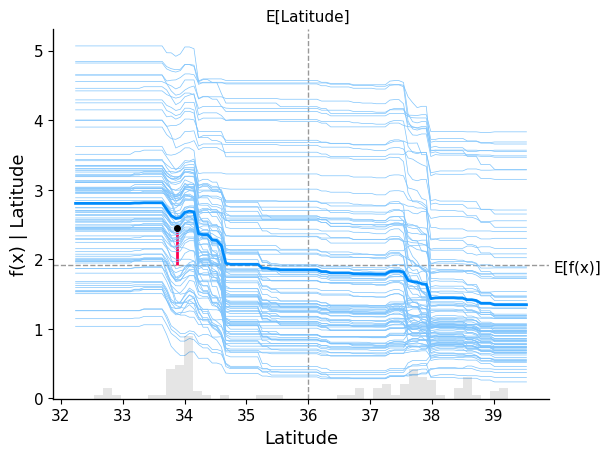

In [14]:
shap.partial_dependence_plot(
    "Latitude",
    model.predict,
    X100,
    ice=True, # Change to false to see only general trend
    model_expected_value=True,
    feature_expected_value=True,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

## Scatter Plot

Once again, we get a clearer view of the non-linearities and interactions in the data. In this scatter plot, SHAP identifies Longitude as the feature most strongly related to the SHAP values of Latitude, and uses it to colour the points.

From the plot, we observe:

- Points in the southeast (low latitude, high longitude – shown in red) are more tightly clustered and have a positive contribution to house prices.
- Points in the northwest (high latitude, low longitude – shown in blue) are more spread out and have a negative contribution to house prices.

We also see clear non-linear transitions:

Around latitude 34–35, the contribution of Latitude shifts from mostly positive to neutral/negative
Around latitude 38, there is a sharper drop, after which Latitude has a strong negative impact on predicted prices

There is a small region around latitude ~38 where some points show a slight positive contribution, but overall, the dominant effect in that range is negative.
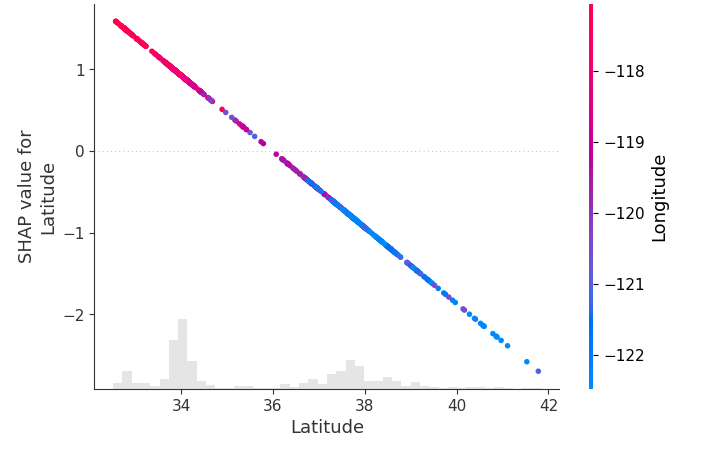

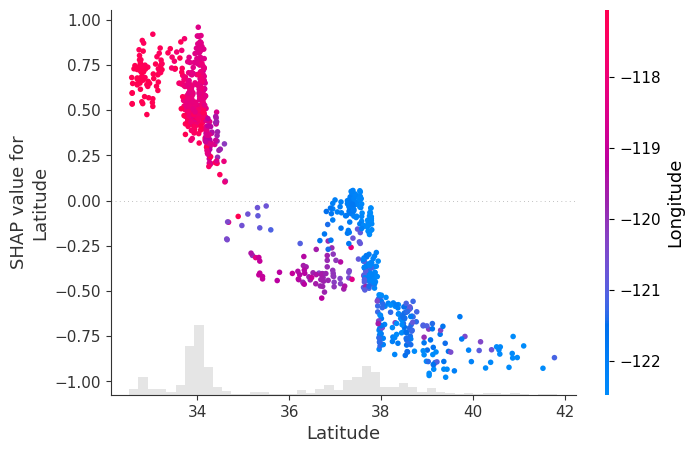

In [15]:
shap.plots.scatter(shap_values[:, "Latitude"], color=shap_values)

## Waterfall Plot

In the waterfall plot, we see that although the direction of influence of most variables remains similar, the magnitude of their contributions changes significantly compared to the linear model.

In this case, we observe that the influence of Latitude and Longitude, which previously dominated the prediction, is now more distributed across other variables:

- Latitude still has a positive contribution, but its effect is noticeably smaller than in the linear model
- Longitude still has a negative contribution, but its magnitude is also reduced, and it is no longer the second most influential variable

Additionally, this model captures effects that the linear regression was not able to identify:

- Average house occupancy (AveOccup) now shows a strong negative contribution for this sample, which was much weaker in the linear model

Overall, the model spreads the contribution across more features, reflecting a more complex set of relationships between the inputs and the predicted house price.

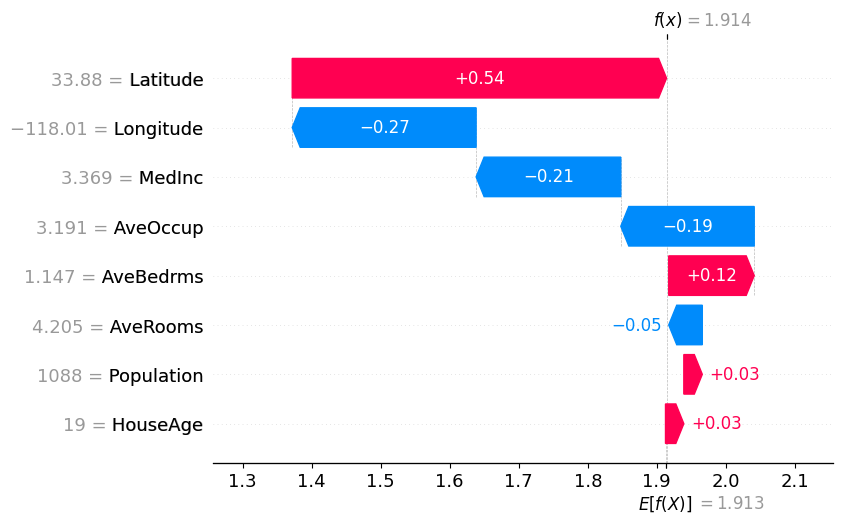

In [16]:
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

## Beeswarm Plot

In this beeswarm plot, we observe that the overall direction of influence of the features is broadly consistent with what we saw in the linear regression model, but the distribution of their effects has changed significantly.

We can see that LightGBM spreads the influence of feature values more evenly across the dataset. Unlike linear regression, we no longer observe a few extreme outliers dominating the predictions. This reflects one of the limitations of linear models, which can be highly sensitive to outliers.

At the same time, the relative importance of the main variables remains similar, with features like Latitude, MedInc, and Longitude still playing a dominant role.

However, we now observe that features that previously had little influence in the linear model contribute more meaningfully to the predictions. This is the case for variables such as HouseAge, AveBedrms, and Population, which now show a wider spread of SHAP values.

Looking more closely:

- For Population, lower values can now lead to both positive and negative contributions, indicating that its effect depends on the context (i.e. interactions with other features)
- A similar pattern appears in AveRooms and Longitude, where both high and low values can produce different impacts depending on the sample

This highlights the key difference with linear regression: the model is no longer assigning a single fixed effect to each feature, but instead capturing non-linear relationships and interactions between variables.

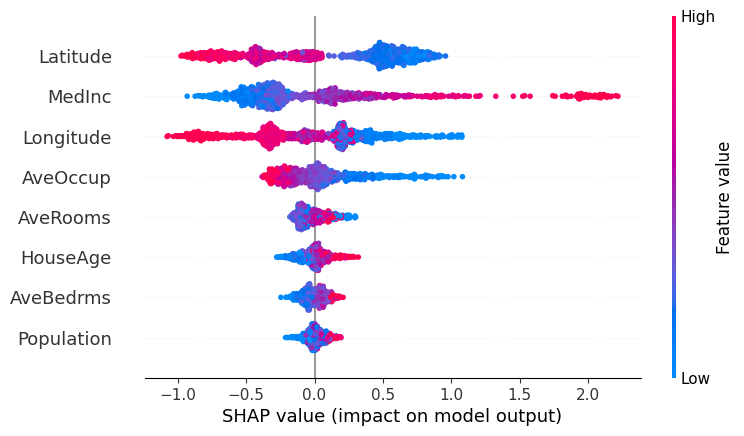

In [17]:
shap.plots.beeswarm(shap_values)

# Final Remarks

Please bear in mind not to interpret these plots with causality in mind (i.e. do not draw strong conclusions from them). The plots we have seen show how a trained model responds to different inputs, but they are not a faithful representation of reality, nor a direct explanation of what truly happens inside the model. Rather, they provide an external approximation to help us understand behaviour that would otherwise be too complex to interpret.

Content in this notebook is heavily inspired by the SHAP documentation:
https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

For a deeper understanding of the theory behind explainability, see:
https://christophm.github.io/interpretable-ml-book/

Please feel free to modify the code used in the plots above to analyse other variables in more detail and extract your own conclusions.